# 

📦 데이터를 불러오는 중...
✅ 데이터 로드 완료! (Train: (299442, 310), Test: (682962, 310))
🖥️ 하드웨어 가속 상태: 🚀 GPU (사용 가능)
🚫 총 141개의 피처가 JSON 설정에 의해 추가 제외됩니다.
📊 최종 학습 피처 수: 163개


🚀 CV 진행률: 100%|██████████| 5/5 [01:29<00:00, 17.81s/it]



📊 [교차 검증] 평균 PR-AUC: 0.7377
  - 표준 편차(std): 0.0046
🎯 [최종 테스트] PR-AUC: 0.3678

🏆 상위 20개 피처:
                  feature    importance
             s198_damaged 490824.421228
             s187_damaged 142791.719603
     total_seeks_28d_asfd  58383.144101
            smart_184_raw  51084.192654
        error_density_14d  38676.224288
              smart_9_raw  29310.527612
      total_seeks_28d_max  23203.241612
       workload_intensity  23003.051753
            smart_242_raw  20649.686821
         total_seeks_diff  20372.579091
            smart_241_raw  20240.438374
              total_seeks  16660.277931
      total_reads_28d_max  14087.537075
            s242_14d_mean  13624.280766
            s242_28d_asfd  12930.913256
             s187_28d_sum  12081.713464
             s198_28d_max  11736.589304
    write_stability_ratio  11659.958712
     total_seeks_14d_mean  11582.084622
reallocated_pending_ratio  11183.953002


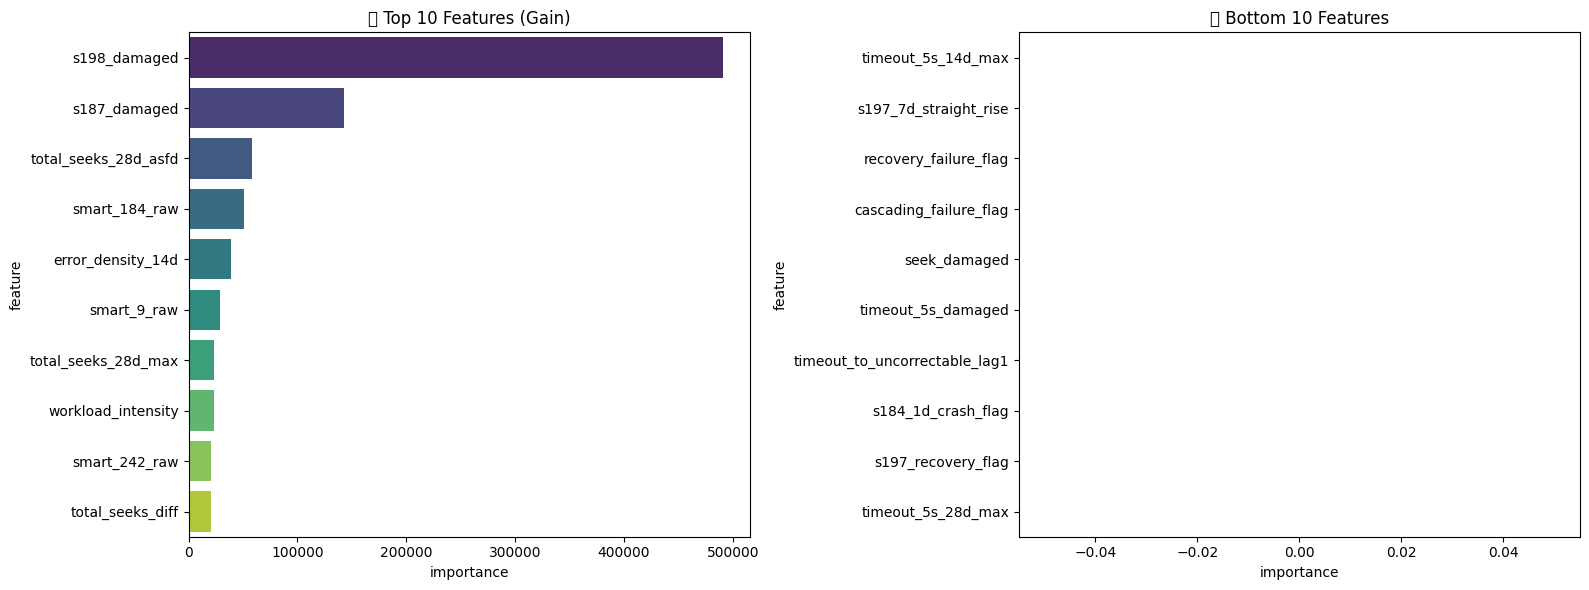


🔮 SHAP 분석 진행 중...


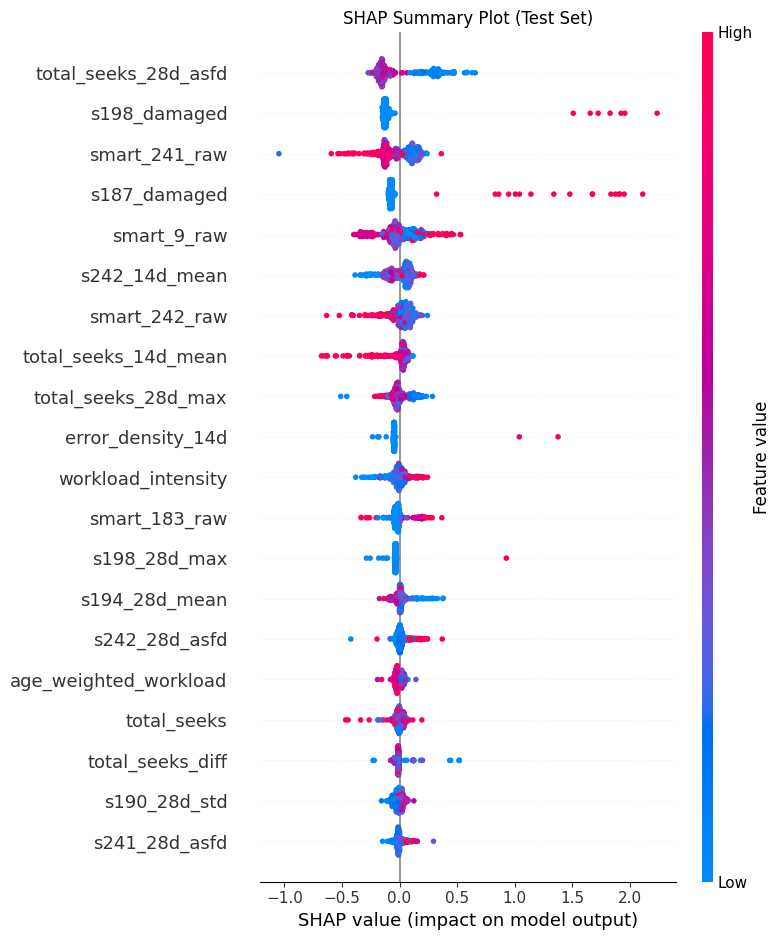

In [ ]:
import pandas as pd
import numpy as np
import lightgbm as lgb
import duckdb
import shap
import json
import os
from tqdm.auto import tqdm
from lightgbm import LGBMClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import average_precision_score
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import logging

warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=UserWarning)
warnings.filterwarnings('ignore')
os.environ['LIGHTGBM_LOG_LEVEL'] = '-1'
logging.getLogger("tqdm").setLevel(logging.ERROR)

def get_exclusion_list(paths):
    exclude_set = set()
    for path in paths:
        if not os.path.exists(path):
            print(f"⚠️ 제외 설정 파일을 찾을 수 없습니다: {path}")
            continue
        with open(path, 'r', encoding='utf-8') as f:
            cfg = json.load(f)
            for key in cfg:
                if isinstance(cfg[key], list):
                    exclude_set.update(cfg[key])
    return list(exclude_set)

# 0. 데이터 경로 및 제외 리스트 설정
train_path = "../data/rfe_sample_data/rfe_sample_train.parquet"
test_path = "../data/rfe_sample_data/rfe_sample_test.parquet"

REMOVE_LISTS = [
    r'..\config\remove_features_v1.json',
    r'..\config\remove_features_v2.json',
]

print("📦 데이터를 불러오는 중...")
train_df = duckdb.query(f"SELECT * FROM '{train_path}'").df()
test_df = duckdb.query(f"SELECT * FROM '{test_path}'").df()
print(f"✅ 데이터 로드 완료! (Train: {train_df.shape}, Test: {test_df.shape})")

# 1. GPU 인식 여부 확인
has_gpu = False
try:
    lgb.train({'device': 'gpu', 'verbose': -1}, lgb.Dataset(np.zeros((1, 1)), label=[0]))
    has_gpu = True
except:
    has_gpu = False
print(f"🖥️ 하드웨어 가속 상태: {'🚀 GPU (사용 가능)' if has_gpu else '💻 CPU (사용 가능)'}")

# 2. 학습/테스트 데이터 분리 (제외 리스트 적용)
base_drop_cols = [
    'failure', 'date', 'serial_number', 
]
drop_cols = [
    'smart_197_raw', 'smart_198_raw', 'smart_187_raw'
]

json_exclude_cols = get_exclusion_list(REMOVE_LISTS)
final_drop_cols = list(set(base_drop_cols + drop_cols + json_exclude_cols))

print(f"🚫 총 {len(json_exclude_cols)}개의 피처가 JSON 설정에 의해 추가 제외됩니다.")

X_train = train_df.drop(columns=final_drop_cols, errors='ignore')
y_train = train_df['failure']

X_test = test_df.drop(columns=final_drop_cols, errors='ignore')
y_test = test_df['failure']

print(f"📊 최종 학습 피처 수: {X_train.shape[1]}개")

# 3. 모델 설정
model = LGBMClassifier(
    objective='binary',
    importance_type='gain', 
    class_weight='balanced',
    max_depth=6,
    num_leaves=40, 
    n_estimators=200, 
    learning_rate=0.07, 
    device='gpu' if has_gpu else 'cpu',
    random_state=42, 
    n_jobs=-1, 
    verbose=-1
)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_scores = []
importances_list = []

# 4. 5-Fold 교차 검증
for train_idx, val_idx in tqdm(list(cv.split(X_train, y_train)), desc="🚀 CV 진행률"):
    X_fold_train, X_fold_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
    y_fold_train, y_fold_val = y_train.iloc[train_idx], y_train.iloc[val_idx]
    
    model.fit(X_fold_train, y_fold_train)
    y_prob = model.predict_proba(X_fold_val)[:, 1]
    cv_scores.append(average_precision_score(y_fold_val, y_prob))
    importances_list.append(model.feature_importances_)

# 5. 테스트 데이터 평가
model.fit(X_train, y_train) 
test_prob = model.predict_proba(X_test)[:, 1]
test_score = average_precision_score(y_test, test_prob)

print(f"\n📊 [교차 검증] 평균 PR-AUC: {np.mean(cv_scores):.4f}")
print(f"  - 표준 편차(std): {np.std(cv_scores):.4f}")
print(f"🎯 [최종 테스트] PR-AUC: {test_score:.4f}")

# 6. 피처 중요도 정리 및 시각화 (Gain 기반)
feat_imp = pd.DataFrame({
    'feature': X_train.columns, 
    'importance': np.mean(importances_list, axis=0)
}).sort_values(by='importance', ascending=False)

print("\n🏆 상위 20개 피처:")
print(feat_imp.head(20).to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sns.barplot(x='importance', y='feature', data=feat_imp.head(10), hue='feature', ax=axes[0], palette='viridis', legend=False)
axes[0].set_title("🏆 Top 10 Features (Gain)")
sns.barplot(x='importance', y='feature', data=feat_imp.tail(10), hue='feature', ax=axes[1], palette='magma', legend=False)
axes[1].set_title("📉 Bottom 10 Features")
plt.tight_layout()
plt.show()

# ---------------------------------------------------------
# 7. SHAP 분석 
# ---------------------------------------------------------
print("\n🔮 SHAP 분석 진행 중...")
X_sample = X_test.sample(500, random_state=42) 
explainer = shap.TreeExplainer(model)
shap_v = explainer.shap_values(X_sample)
sv = shap_v[1] if isinstance(shap_v, list) else shap_v

# ==========================================
# 🎨 [수정된 부분] SHAP 색칠을 위한 데이터 정제
# ==========================================
# 1. 깐깐한 정수형(Int64) 타입을 모두 관대한 실수형(float64)으로 강제 변환
X_color = X_sample.astype('float64')

# 2. 이제 소수점이 있는 중앙값도 에러 없이 아주 잘 들어감!
X_color = X_color.fillna(X_color.median())
# ==========================================

# 요약 플롯 (기여도 분포)
plt.figure(figsize=(10, 8))
plt.title("SHAP Summary Plot (Test Set)")

# features 인자에 보정된 X_color를 넣음
shap.summary_plot(sv, features=X_color, max_display=20)